# Figure Generation
Publication figures for hinspheres paper. Each figure in its own cell.

Label convention: (a), (b) placed OUTSIDE axes, below each panel.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
warnings.filterwarnings('ignore')

import numpy as np
from astropy.io import fits as pyfits
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d

from hinspheres import Config, generate_sim_hinsa
from hinspheres.profiles import density_plummer, temperature_plummer

plt.style.use('lindon.mplstyle')

OUT_DIR = Path('figures'); OUT_DIR.mkdir(exist_ok=True)
CORES_DIR = Path('synthetic_cores_v2')
TMP_DIR = Path('.tmp_figures'); TMP_DIR.mkdir(exist_ok=True)

AGES = [1e5, 5e6, 1e7, 5e8]
STAGES = [r'1e5yr', r'5e6yr', r'1e7yr', r'5e8yr']
LABELS = [r'$10^5$ yr', r'$5\times10^6$ yr', r'$10^7$ yr', r'$5\times10^8$ yr']

N0 = 1.6e4; R_OUT = 1.46; R_PLUMMER = 0.146; ALPHA = 2.0
T_CORE = 10.0; T_EDGE = 58.0; R_T = 0.73; DIST = 300.0
SIGMA_TURB = 0.2; V_ROT = 0.2; ROT_PA = 45.0
K_FORM = 1.2e-17; ZETA_CR = 5.2e-17
PIX_SCALE_ARCMIN = 1.5; BEAM_ARCMIN = 3.0

def hi_abundance(t_yr, n_local):
    tau_s = 1.0 / (2.0 * K_FORM * n_local + ZETA_CR)
    tau_yr = tau_s / 3.156e7
    rate_ratio = 2.0 * K_FORM * n_local / (2.0 * K_FORM * n_local + ZETA_CR)
    return np.clip(1.0 - rate_ratio * (1.0 - np.exp(-t_yr / tau_yr)), 0.0, 1.0)

def plummer_density(r, n0, r0, alpha):
    return n0 / (1.0 + (r / r0)**2)**(alpha / 2.0)

def temperature_profile(r, T0_, T1_, rT):
    return T1_ + (T0_ - T1_) / (1.0 + (r / rT)**2)

def load_sim_cube(stage):
    path = CORES_DIR / f'core_{stage}_sim.fits'
    hdul = pyfits.open(str(path))
    cube = hdul[0].data.astype(np.float64)
    hdr = hdul[0].header; hdul.close()
    crval3 = hdr.get('CRVAL3', 0.0)
    cdelt3 = hdr.get('CDELT3', 200.0)
    crpix3 = hdr.get('CRPIX3', 1)
    velo = (crval3 + (np.arange(cube.shape[0]) - (crpix3-1)) * cdelt3) / 1000.0
    return cube, velo, hdr

def load_background():
    bg_path = CORES_DIR / 'L1574_background_regridded.fits'
    hdul = pyfits.open(str(bg_path))
    bg_cube = hdul[0].data.astype(np.float64)
    bg_hdr = hdul[0].header; hdul.close()
    crval3 = bg_hdr.get('CRVAL3', 0.0)
    cdelt3 = bg_hdr.get('CDELT3', 200.0)
    crpix3 = bg_hdr.get('CRPIX3', 1)
    bg_velo = (crval3 + (np.arange(bg_cube.shape[0]) - (crpix3-1)) * cdelt3) / 1000.0
    return bg_cube, bg_velo, bg_hdr

print('Setup done.')

Setup done.


## Figure 1 — Physical model (4 panels)

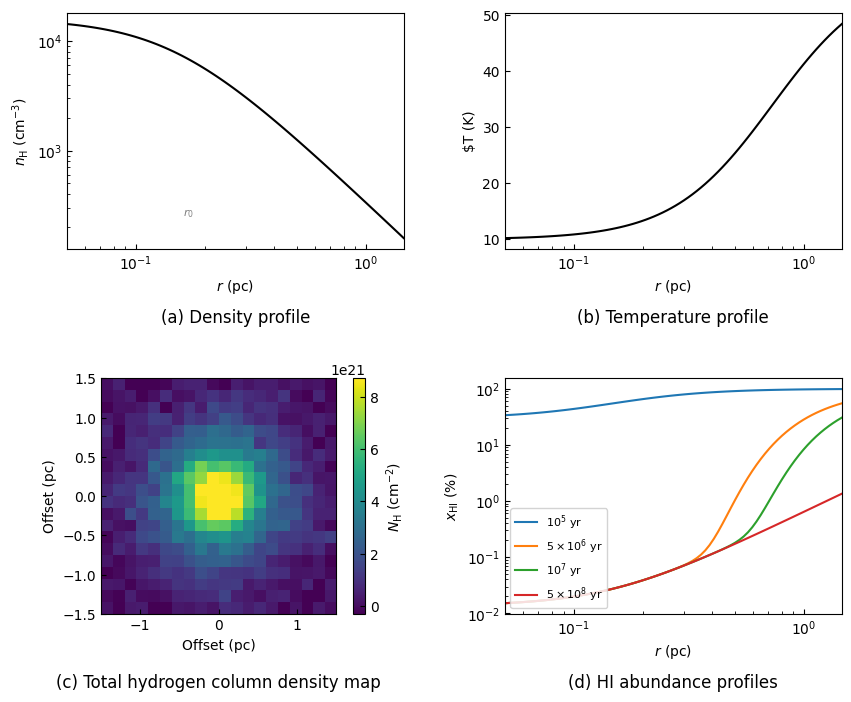

In [53]:
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import gridspec
    from pathlib import Path
    import astropy.io.fits as pyfits
    %matplotlib inline


    r = np.logspace(np.log10(0.05), np.log10(R_OUT), 80)
    n = plummer_density(r, N0, R_PLUMMER, ALPHA)
    T = temperature_profile(r, T_CORE, T_EDGE, R_T)

    fig = plt.figure(figsize=(10, 7.8),constrained_layout=True)
    gs = gridspec.GridSpec(2, 2, hspace=0.55, wspace=0.30)

    panel_axes = []

    # (a) Density + temperature (dual y-axis)
    ax1 = fig.add_subplot(gs[0, 0])
    panel_axes.append(ax1)
    ax1.plot(r, n, color='black')
    ax1.set_xscale('log'); ax1.set_yscale('log')
    ax1.set_xlabel(r'$r$ (pc)')
    ax1.set_ylabel(r'$n_\mathrm{H}$ (cm$^{-3}$)')
    ax1.set_xlim(r[0], r[-1])
    ax1.text(R_PLUMMER * 1.1, ax1.get_ylim()[0] * 2,
             r'$r_0$', fontsize=8, color='gray')
    
    lns = [Line2D([0], [0], color='black')]
    #ax1.legend(lns, [r'$n_\mathrm{H}$'],loc='upper right',fontsize=8)

    # (a) Density + temperature (dual y-axis)
    ax1 = fig.add_subplot(gs[0, 1])
    panel_axes.append(ax1)
    ax1.plot(r, T, color='black')
    ax1.set_ylabel(r'$T (K)')
    #ax1.text(R_T * 1.1, 5, r'$r_T$', fontsize=8, color='gray')
    ax1.set_xlim(r[0], r[-1])
    ax1.set_xlabel(r'$r$ (pc)')
    ax1.set_xscale('log')
    lns = [Line2D([0], [0])]
    #ax1.legend(lns, [r'$T_\mathrm{spin}$'],fontsize=8, loc='upper right')

    # (b) HI abundance
    #r = np.logspace(np.log10(0.01), np.log10(R_OUT*5), 80)
    #n = plummer_density(r, N0, R_PLUMMER, ALPHA)
    
    ax = fig.add_subplot(gs[1, 1])
    panel_axes.append(ax)
    for i, age in enumerate(AGES):
        x = np.array([hi_abundance(age, n_j) for n_j in n])
        ax.plot(r, x * 100, label=LABELS[i])
    ax.set_xscale('log')
    ax.set_xlabel(r'$r$ (pc)')
    ax.set_ylabel(r'$x_\mathrm{HI}$ (%)')
    ax.set_xlim(r[0], r[-1])
    ax.set_yscale('log')
    ax.legend(fontsize=8, loc='lower left', framealpha=0.85)

    # (c) nh_noisy_planck
    ax = fig.add_subplot(gs[1, 0])
    panel_axes.append(ax)
    nh_path = 'nh_noisy_planck.fits'
    nh_data = pyfits.getdata(str(nh_path)).astype(np.float64)
    hdr_nh = pyfits.getheader(str(nh_path))
    pixsc = hdr_nh.get('PIXELSC', 0.150)
    ny_nh, nx_nh = nh_data.shape
    extent = [-nx_nh * pixsc / 2, nx_nh * pixsc / 2, -ny_nh * pixsc/ 2, ny_nh * pixsc/ 2]
    im = ax.imshow(nh_data, origin='lower', cmap='viridis',
                   extent=extent,vmin=np.percentile(nh_data, 5), vmax=np.percentile(nh_data, 98))
    ax.set_xlabel(r'Offset (pc)')
    ax.set_ylabel(r'Offset (pc)')
    plt.colorbar(im, ax=ax).set_label(
        r'$N_{\rm H}$ (cm$^{-2}$)')

    # (d) L1574 background
    if 0:
        ax = fig.add_subplot(gs[1, 1])
        panel_axes.append(ax)
        lbg_path = '/home/olozhika/文档/OpenScience/hinspheres/L1574_HI_background.fits'
        hdul = pyfits.open(str(lbg_path))
        lbg_data = hdul[0].data.astype(np.float64)
        lbg_hdr = hdul[0].header
        hdul.close()
        crval3_l = lbg_hdr.get('CRVAL3', 0.0)
        cdelt3_l = lbg_hdr.get('CDELT3', 184.0)
        crpix3_l = lbg_hdr.get('CRPIX3', 1)
        lbg_velo = (crval3_l + (np.arange(lbg_data.shape[0])
                    - (crpix3_l - 1)) * cdelt3_l) / 1000.0
        vmask = np.abs(lbg_velo) <= 1.0
        dv_lbg = abs(lbg_velo[1] - lbg_velo[0])
        lbg_mom0 = np.sum(lbg_data[vmask, :, :], axis=0) * dv_lbg
        pix_phys = abs(lbg_hdr.get('CDELT1', 0.016667)) * np.pi / 180.0 * DIST
        ny_l, nx_l = lbg_data.shape[1:]
        im = ax.imshow(lbg_mom0, origin='lower', extent=[0, nx_l * pix_phys, 0, ny_l * pix_phys])
        ax.set_xlabel(r'$x$ (pc)')
        ax.set_ylabel(r'$y$ (pc)')
        plt.colorbar(im, ax=ax).set_label(
            r'K km s$^{-1}$', fontsize=9)

    # ===== 在每个子图下方添加 (a) xxxxxx 标签 =====
    subplot_labels = [
        '(a) Density profile',
        '(b) Temperature profile',
        '(d) HI abundance profiles',
        '(c) Total hydrogen column density map',
    ]

    for ax, lab in zip(panel_axes, subplot_labels):
        # 将标签放在子图下方，向左对齐
        #ax.annotate(lab, xy=(0, -0.30), xycoords='axes fraction')
        ax.set_title(lab,y=-0.35)

    plt.savefig('./figures/fig1.pdf', bbox_inches='tight')

## Figure 2 — Absorption maps + pixel spectra (4 rows x 2 columns)

<Figure size 800x1200 with 9 Axes>


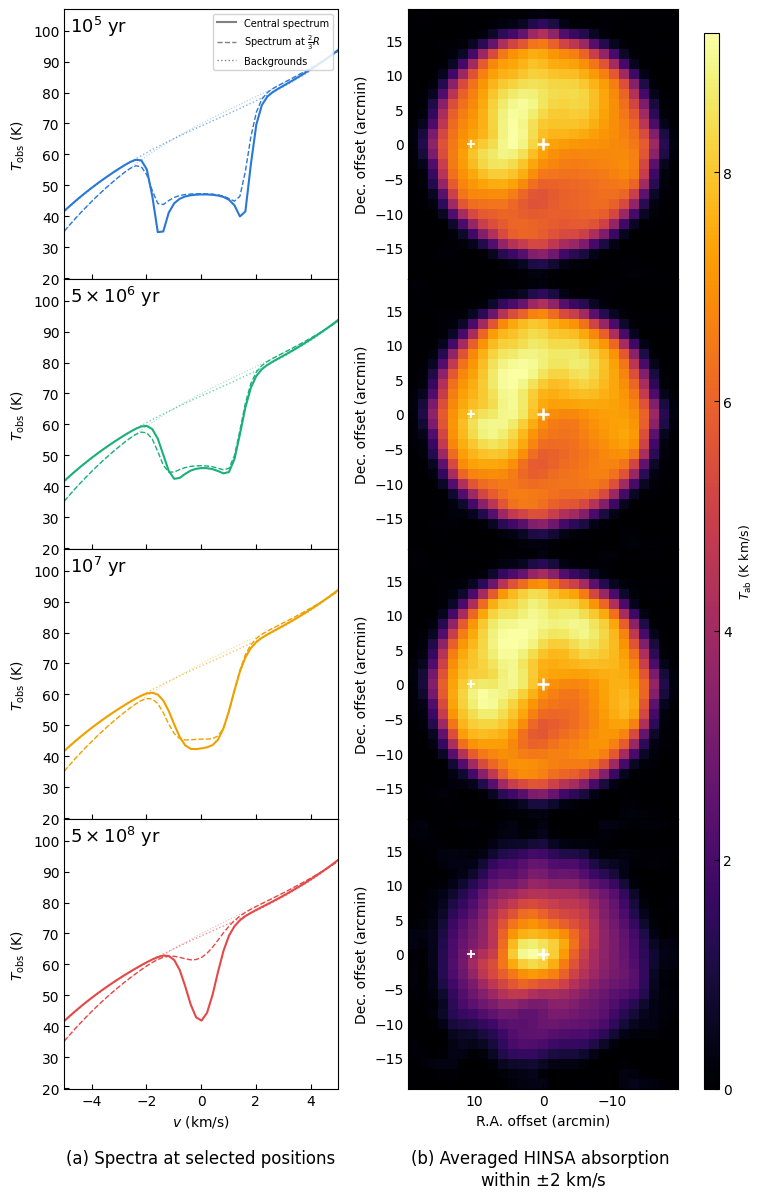

In [ ]:
bg_cube, bg_velo, _ = load_background()
%matplotlib inline

fig = plt.figure(figsize=(8, 12))  # 去掉 constrained_layout
# 设置 GridSpec，hspace=0, wspace=0，并调整左右边距为 colorbar 留位
gs = gridspec.GridSpec(4, 2, hspace=0, wspace=0.25,
                       left=0.08, right=0.85, bottom=0.06, top=0.96)
# colorbar 位置稍向右移
cax = fig.add_axes([0.88, 0.06, 0.018, 0.88])

im_last = None
col1_axes = []  # 左列谱线
col2_axes = []  # 右列吸收图

# 用于共享 x 轴的占位变量
first_left_ax = None
first_right_ax = None

for row, (stage, c, label) in enumerate(zip(STAGES, PALETTE, LABELS)):
    cube, velo, hdr = load_sim_cube(stage)
    bg_interp = interp1d(bg_velo, bg_cube, kind='linear', axis=0,
                         bounds_error=False, fill_value='extrapolate')
    bg_at_cube = bg_interp(velo)
    n_v, ny, nx = cube.shape
    cy, cx = ny//2, nx//2
    dv_kms = abs(velo[1] - velo[0])
    r2_3_px = int(round(0.66 * R_OUT / 0.1309))

    pix_to_arcmin = PIX_SCALE_ARCMIN
    half_nx = (nx-1)/2.0; half_ny = (ny-1)/2.0
    extent_arcmin = [half_nx*pix_to_arcmin, -half_nx*pix_to_arcmin,
                     -half_ny*pix_to_arcmin, half_ny*pix_to_arcmin]

    # --- 左列：谱线（共享 x 轴）---
    if row == 0:
        ax_left = fig.add_subplot(gs[row, 0])
        first_left_ax = ax_left
    else:
        ax_left = fig.add_subplot(gs[row, 0], sharex=first_left_ax)
    ax_left.plot(velo, cube[:, cy, cx], color=c, lw=1.5)
    ax_left.plot(velo, bg_at_cube[:, cy, cx], color=c, lw=1.0, ls=':', alpha=0.6)
    px_r2 = min(cx + r2_3_px, nx-1)
    if px_r2 > cx:
        ax_left.plot(velo, cube[:, cy, px_r2], color=c, lw=1.0, ls='--')
        ax_left.plot(velo, bg_at_cube[:, cy, px_r2], color=c, lw=0.8, ls=':', alpha=0.4)
    ax_left.set_xlim(-5, 5)
    if row < 3:
        plt.setp(ax_left.get_xticklabels(), visible=False)  # 隐藏非底行的 x 轴标签
    else:
        ax_left.set_xlabel(r'$v$ (km/s)')
    ax_left.set_ylabel(r'$T_{\rm obs}$ (K)')
    
    ax_left.text(0.02, 0.98, label, transform=ax_left.transAxes,
                 va='top', ha='left', fontsize=13, color='black',
                 bbox=dict(facecolor='white', alpha=0, edgecolor='none'))
    
    if row == 0:
        ax_left.legend(handles=[Line2D([0],[0],color='gray',lw=1.5),
                                Line2D([0],[0],color='gray',lw=1,ls='--'),
                                Line2D([0],[0],color='gray',lw=1,ls=':')],
                       labels=['Central spectrum', r'Spectrum at $\frac{2}{3}R$', 'Backgrounds'],
                       fontsize=7, loc='upper right', framealpha=0.85)
    col1_axes.append(ax_left)

    # --- 右列：吸收图（共享 x 轴）---
    if row == 0:
        ax_right = fig.add_subplot(gs[row, 1])
        first_right_ax = ax_right
    else:
        ax_right = fig.add_subplot(gs[row, 1], sharex=first_right_ax)

    # 替换原来的 v_mask 和 mom0 计算部分
    v_mask = np.abs(velo) <= 2.0
    delta = bg_at_cube - cube
    integral = np.sum(np.clip(delta, 0, None)[v_mask], axis=0) * dv_kms
    mom0 = integral / 4.0
    
    im = ax_right.imshow(mom0, origin='lower', cmap='inferno',
                         extent=extent_arcmin,
                         #vmin=np.percentile(mom0, 5), vmax=np.percentile(mom0, 95),
                        )
    im_last = im
    ax_right.plot(0, 0, '+', color='white', ms=9, mew=1.8)
    ax_right.plot(r2_3_px*pix_to_arcmin, 0, '+', color='white', ms=6, mew=1.3)
    if row < 3:
        plt.setp(ax_right.get_xticklabels(), visible=False)
    else:
        ax_right.set_xlabel(r'R.A. offset (arcmin)')
    if 1:
        ax_right.set_ylabel(r'Dec. offset (arcmin)')
    col2_axes.append(ax_right)

# Shared colorbar
plt.colorbar(im_last, cax=cax).set_label(
    r'$T_{\rm ab}$ (K km/s)', fontsize=9)

# Labels below the bottom row
for ax, lab in zip([col1_axes[-1], col2_axes[-1]], ['(a) Spectra at selected positions', '(b) Averaged HINSA absorption \nwithin $\pm$2 km/s']):
    bbox = ax.get_position()
    fig.text((bbox.x0+bbox.x1)/2, bbox.y0 - 0.05, lab,
             ha='center', va='top', fontsize=12)

plt.savefig(str(OUT_DIR / 'fig2.pdf'), bbox_inches='tight')

## Figure 3 — HI abundance + absorption spectra

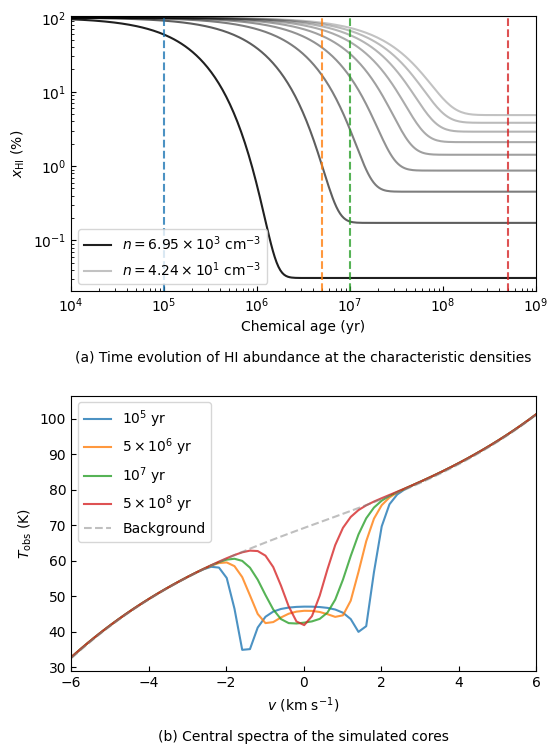

fig3 saved (axes independent).


In [54]:
%matplotlib inline
# ============================================================
# Figure 3 绘制（修正：x轴完全独立，上对数下线性）
# ============================================================

cfg_local = Config(n_shells=9, R_out=R_OUT)
r_mid = cfg_local.r_mid
n_H = density_plummer(r_mid, N0, R_PLUMMER, ALPHA)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:4]

fig = plt.figure(figsize=(6, 8.5))
gs = gridspec.GridSpec(2, 1,hspace=0.38)

ax0 = fig.add_subplot(gs[0])   # 上：HI丰度
ax1 = fig.add_subplot(gs[1])   # 下：谱线，不共享x轴

# ---- 上方面板：Goldsmith & Li (2005) HI 丰度 ----
t_arr = np.logspace(3, 9, 300)                     # 1e3 ~ 1e9 yr

def sci(num, prec=2):
    m, e = f"{num:.{prec}e}".split('e')
    return f"${m}\\times 10^{{{int(e)}}}$"
#N_out=plummer_density(R_OUT, N0, R_PLUMMER, ALPHA)
for nn in n_H:#np.logspace(np.log10(N0), np.log10(N_out), 5):
    xHI_percent = hi_abundance(t_arr, nn) * 100.0      # 使用 N0 代表 n
    if nn not in [n_H[0],n_H[-1]]:
        ax0.plot(t_arr, xHI_percent, color='black', alpha = (np.log10(nn)/np.log10(N0))**1.5)
    else:
        ax0.plot(t_arr, xHI_percent, color='black', alpha = (np.log10(nn)/np.log10(N0))**1.5, label='$n=$'+sci(nn)+' cm$^{-3}$')

ax0.set_ylabel(r'$x_{\mathrm{HI}}$ (%)')
ax0.set_xscale('log')                  # 对数刻度
ax0.set_yscale('log')                  # 对数刻度
ax0.set_xlim(1e4, 1e9)                 # 严格范围
ax0.set_ylim(0, 105)
ax0.legend()
ax0.set_xlabel(r'Chemical age (yr)')

# 四个时间点标记
for i, age in enumerate(AGES):
    color = colors[i]
    ax0.axvline(age, ls='--', lw=1.5, color=color, alpha=0.8,
                )

# ---- 下方面板：吸收谱线 ----
bg_cube, bg_velo, _ = load_background()
bg_interp = interp1d(bg_velo, bg_cube, kind='linear', axis=0,
                     bounds_error=False, fill_value='extrapolate')

for i, stage in enumerate(STAGES):
    cube, velo, _ = load_sim_cube(stage)
    cy, cx = cube.shape[1] // 2, cube.shape[2] // 2
    bg_at = bg_interp(velo)                         # 插值到当前速度网格
    spectrum = cube[:, cy, cx]   # 吸收差分
    ax1.plot(velo, spectrum, color=colors[i], label=LABELS[i],alpha=0.8)

ax1.plot(velo, bg_at[:, cy, cx], color='grey', ls='--',alpha=0.5,label='Background')
ax1.set_xlabel(r'$v$ (km s$^{-1}$)')
ax1.set_ylabel(r'$T_{\rm obs}$ (K)')
ax1.set_xlim(-6, 6)          # 固定速度范围
ax1.legend()

# ---- 子图标签 (a) 与 (b) ----
for ax, lab in zip([ax0, ax1], ['(a) Time evolution of HI abundance at the characteristic densities', '(b) Central spectra of the simulated cores']):
    bbox = ax.get_position()
    fig.text((bbox.x0 + bbox.x1) / 2, bbox.y0 - 0.07, lab,
             ha='center', va='top')

plt.savefig(str(OUT_DIR / 'fig3.pdf'), bbox_inches='tight')
plt.show()
print('fig3 saved (axes independent).')